# Student Performance Prediction Project

## Project Description
This project focuses on predicting a student's **final exam outcome** (pass or fail) based on their study habits, engagement level, prior experience, and performance throughout an online programming course. The goal is to analyze learning behavior patterns and identify which factors contribute most to student success.

## Objective
Build a machine learning model that predicts whether a student will pass or fail the final exam using various behavioral and performance-related features.

This project helps:
* Identify studentat-risks early
* Recommend personalized interventions
* Understand patterns behind successful learners

## Dataset Overview
The dataset contains several attributes capturing demographic information, study patterns, engagement metrics, and performance indicators. The key columns include:

### **1. student_id**
Unique identifier assigned to each student.

### **2. age**
Age of the student.

### **3. country**
Country of student.

### **4. prior_programming_experience**
Indicates whether the student had any programming experience before taking the course.

### **5. weeks_in_course**
Total Number of weeks the student has been enrolled in the course.

### **6. hours_spent_learning_per_week**
Average weekly hours spent studying.

### **7. practice_problems_solved**
Number of practice problems student solved.

### **8. projects_completed**
Total count of projects completed.

### **9. tutorial_videos_watched**
Number of tutorial watched.

### **10. uses_kaggle**
Whether the student uses Kaggle for practice.

### **11. participates_in_discussion_forums**
Indicates if the student participates in class or online discussion forums.

### **12. debugging_sessions_per_week**
How many debugging or troubleshooting sessions the student attends weekly.

### **13. self_reported_confidence_python**
A self-rated measure of the student's confidence in Python programming.

### **14. final_exam_score**
Score achieved in the final exam.

### **15. passed_exam**
Binary target variable indicating whether the student passed the exam or not.

## Project Goals
* Conduct data cleaning and exploratory data analysis (EDA)
* Identify relationships between study habits and final exam performance
* Perform Feature Engineering and Feature Selection.
* Train multiple machine learning models to predict **passed_exam**
* Compare performance metrics across models
* Highlight key features influencing exam outcomes
* Build a user-friendly **Streamlit app** for prediction

## Expected Outcomes
* Insights into study behaviors that impact learning outcomes
* Deployed app for real-time prediction


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("python.csv")
df.head()

,student_id,age,country,prior_programming_experience,weeks_in_course,hours_spent_learning_per_week,practice_problems_solved,projects_completed,tutorial_videos_watched,uses_kaggle,participates_in_discussion_forums,debugging_sessions_per_week,self_reported_confidence_python,final_exam_score,passed_exam
0,1,54,Pakistan,Beginner,12,12.2,60,1,24,0,1,4,10,53.8,0
1,2,44,Nigeria,NaN,15,14.2,52,1,32,0,0,5,7,31.9,0
2,3,30,India,Intermediate,5,7.7,71,1,43,0,0,6,3,59.4,0
3,4,23,Nigeria,Beginner,4,5.6,64,2,40,1,0,3,10,58.8,0
4,5,36,UK,NaN,3,3.5,62,1,47,1,0,3,7,24.8,0


In [3]:
df.shape

(3000, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   student_id                         3000 non-null   int64  
 1   age                                3000 non-null   int64  
 2   country                            3000 non-null   object 
 3   prior_programming_experience       1938 non-null   object 
 4   weeks_in_course                    3000 non-null   int64  
 5   hours_spent_learning_per_week      3000 non-null   float64
 6   practice_problems_solved           3000 non-null   int64  
 7   projects_completed                 3000 non-null   int64  
 8   tutorial_videos_watched            3000 non-null   int64  
 9   uses_kaggle                        3000 non-null   int64  
 10  participates_in_discussion_forums  3000 non-null   int64  
 11  debugging_sessions_per_week        3000 non-null   int64

In [5]:
df.describe()

,student_id,age,weeks_in_course,hours_spent_learning_per_week,practice_problems_solved,projects_completed,tutorial_videos_watched,uses_kaggle,participates_in_discussion_forums,debugging_sessions_per_week,self_reported_confidence_python,final_exam_score,passed_exam
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,35.327000,8.121000,7.035267,59.983667,2.001333,39.896667,0.400667,0.498333,4.973333,5.566000,43.318267,0.177333
std,866.169729,11.302182,4.275019,2.936134,7.713056,1.395701,6.263258,0.490115,0.500081,2.236729,2.885207,17.376666,0.382014
min,1.000000,16.000000,1.000000,0.000000,35.000000,0.000000,19.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,750.750000,26.000000,5.000000,5.000000,55.000000,1.000000,35.000000,0.000000,0.000000,3.000000,3.000000,30.900000,0.000000
50%,1500.500000,36.000000,8.000000,7.000000,60.000000,2.000000,40.000000,0.000000,0.000000,5.000000,6.000000,43.100000,0.000000
75%,2250.250000,45.000000,12.000000,9.000000,65.000000,3.000000,44.000000,1.000000,1.000000,6.000000,8.000000,55.600000,0.000000
max,3000.000000,54.000000,15.000000,17.100000,87.000000,9.000000,63.000000,1.000000,1.000000,17.000000,10.000000,100.000000,1.000000


In [6]:
df.isnull().sum()

student_id                              0
age                                     0
country                                 0
prior_programming_experience         1062
weeks_in_course                         0
hours_spent_learning_per_week           0
practice_problems_solved                0
projects_completed                      0
tutorial_videos_watched                 0
uses_kaggle                             0
participates_in_discussion_forums       0
debugging_sessions_per_week             0
self_reported_confidence_python         0
final_exam_score                        0
passed_exam                             0
dtype: int64

In [7]:
df["prior_programming_experience"].value_counts()

prior_programming_experience
Beginner        1034
Intermediate     634
Advanced         270
Name: count, dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Overview

Dataset Shape: 3000 rows × 15 columns
Data Types: 2 float, 11 integer, 2 object columns

Missing Values:
1. prior_programming_experience has ~1060 null values
2. These are not real missing values → they indicate no prior experience
3. Duplicates: No duplicate records found

Overall Data Status: Dataset is clean.

## Data Cleaning

In [9]:
df.head()

,student_id,age,country,prior_programming_experience,weeks_in_course,hours_spent_learning_per_week,practice_problems_solved,projects_completed,tutorial_videos_watched,uses_kaggle,participates_in_discussion_forums,debugging_sessions_per_week,self_reported_confidence_python,final_exam_score,passed_exam
0,1,54,Pakistan,Beginner,12,12.2,60,1,24,0,1,4,10,53.8,0
1,2,44,Nigeria,NaN,15,14.2,52,1,32,0,0,5,7,31.9,0
2,3,30,India,Intermediate,5,7.7,71,1,43,0,0,6,3,59.4,0
3,4,23,Nigeria,Beginner,4,5.6,64,2,40,1,0,3,10,58.8,0
4,5,36,UK,NaN,3,3.5,62,1,47,1,0,3,7,24.8,0


In [10]:
df.dtypes

student_id                             int64
age                                    int64
country                               object
prior_programming_experience          object
weeks_in_course                        int64
hours_spent_learning_per_week        float64
practice_problems_solved               int64
projects_completed                     int64
tutorial_videos_watched                int64
uses_kaggle                            int64
participates_in_discussion_forums      int64
debugging_sessions_per_week            int64
self_reported_confidence_python        int64
final_exam_score                     float64
passed_exam                            int64
dtype: object

In [11]:
df.drop("student_id",axis=1,inplace=True)

In [12]:
df["prior_programming_experience"].fillna("No",inplace=True)

In [13]:
df["prior_programming_experience"].value_counts()

prior_programming_experience
No              1062
Beginner        1034
Intermediate     634
Advanced         270
Name: count, dtype: int64

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.dropna(inplace=True)

In [16]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip()

In [17]:
df.shape

(3000, 14)

## Data Cleaning Summary

During the data cleaning process, the following steps were performed:

### Dropped Irrelevant Column
Removed student_id since it does not contribute to the prediction task.

### Handled Missing Values
1. The column prior_programming_experience contained many null values.
2. These nulls logically represent no prior experience, so they were filled with "no".
3. Removed Duplicate Records
4. Removed Remaining NA Values
5. Cleaned Whitespace in Categorical Variables

Data is now cleaned and ready for Eda and preprocessing.

## EDA

### Bivariate Eda

In [18]:
df.head()

,age,country,prior_programming_experience,weeks_in_course,hours_spent_learning_per_week,practice_problems_solved,projects_completed,tutorial_videos_watched,uses_kaggle,participates_in_discussion_forums,debugging_sessions_per_week,self_reported_confidence_python,final_exam_score,passed_exam
0,54,Pakistan,Beginner,12,12.2,60,1,24,0,1,4,10,53.8,0
1,44,Nigeria,No,15,14.2,52,1,32,0,0,5,7,31.9,0
2,30,India,Intermediate,5,7.7,71,1,43,0,0,6,3,59.4,0
3,23,Nigeria,Beginner,4,5.6,64,2,40,1,0,3,10,58.8,0
4,36,UK,No,3,3.5,62,1,47,1,0,3,7,24.8,0


<Axes: xlabel='passed_exam', ylabel='count'>

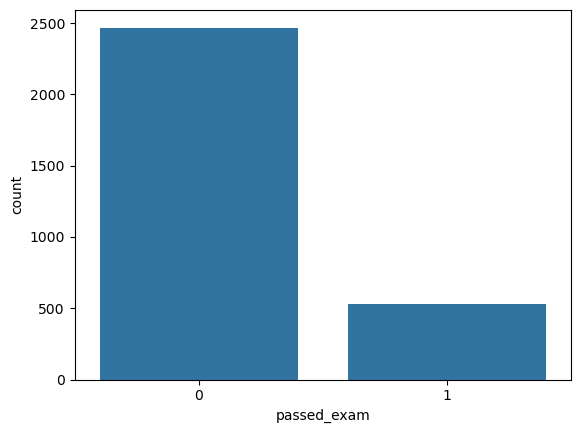

In [19]:
sns.countplot(x = "passed_exam",data=df)

The countplot clearly shows a significant imbalance in the target variable:
1. More than 2400 students failed the exam
2. Around 500 students passed the exam

This indicates that the dataset is heavily skewed toward the failed category. 

<Axes: xlabel='age', ylabel='Count'>

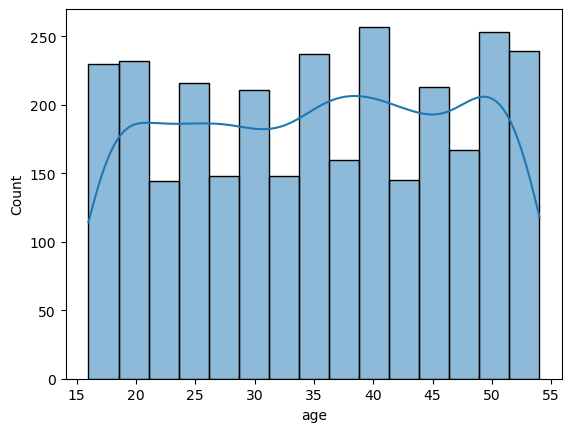

In [20]:
sns.histplot(x = "age",data=df,kde=True)

- The histogram shows that the student ages range from 16 to 53 years.
- The distribution appears fairly uniform, indicating that learners from all age groups are almost equally represented in the dataset.

- This balanced spread suggests that age does not dominate the dataset, and further analysis will help determine whether age has any meaningful impact on exam performance.

<Axes: xlabel='hours_spent_learning_per_week', ylabel='Count'>

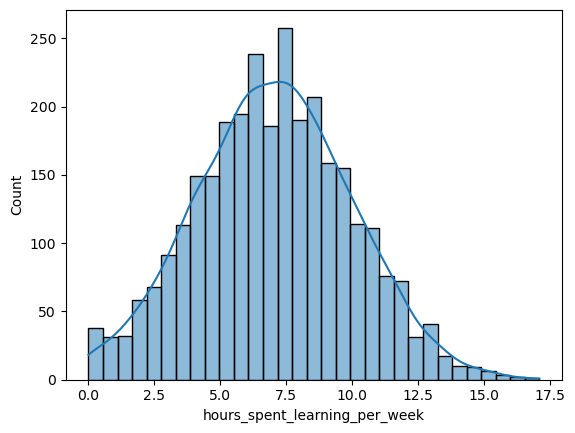

In [21]:
sns.histplot(x="hours_spent_learning_per_week",data=df,kde=True)

The histogram shows that the number of weekly study hours is normally distributed.
- Students’ study time ranges from 0 hours up to more than 15 hours per week.

- A clear concentration can be seen in the 5 to 10 hour range, 
- indicating that most students fall within this study pattern.
- This provides an important insight into typical study behavior and will be useful later when examining its impact on exam performance.

In [22]:
df.columns

Index(['age', 'country', 'prior_programming_experience', 'weeks_in_course',
       'hours_spent_learning_per_week', 'practice_problems_solved',
       'projects_completed', 'tutorial_videos_watched', 'uses_kaggle',
       'participates_in_discussion_forums', 'debugging_sessions_per_week',
       'self_reported_confidence_python', 'final_exam_score', 'passed_exam'],
      dtype='object')

<Axes: xlabel='practice_problems_solved', ylabel='Count'>

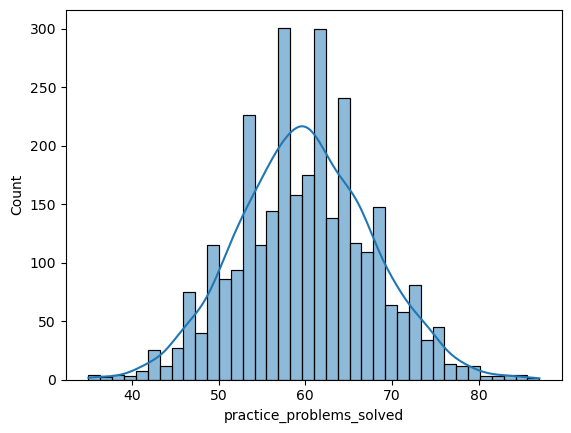

In [23]:
sns.histplot(x = "practice_problems_solved",data=df,kde=True)

- The distribution appears roughly normal, with most students falling within a consistent range.
- Students typically solved between 30 to 90 practice problems, and the highest concentration lies around the 55 to 65 problem range.

<Axes: xlabel='projects_completed', ylabel='count'>

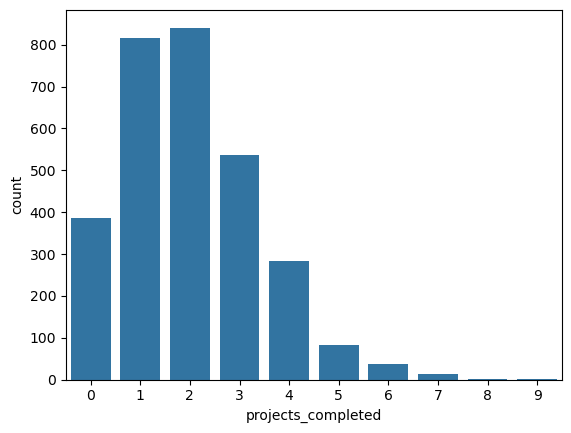

In [24]:
sns.countplot(data=df, x='projects_completed')

- The number of completed projects ranges from 0 to 9.
- Around 400 students have completed 0 project.
-  1–2 projects are the most common, completed by roughly 1600 students.
- About 500 students have completed 3 projects, and around 300 students completed 4 projects.
- Only 20–30 students have completed 5 to 9 projects, showing that higher project completion is rare.

<Axes: xlabel='tutorial_videos_watched', ylabel='Count'>

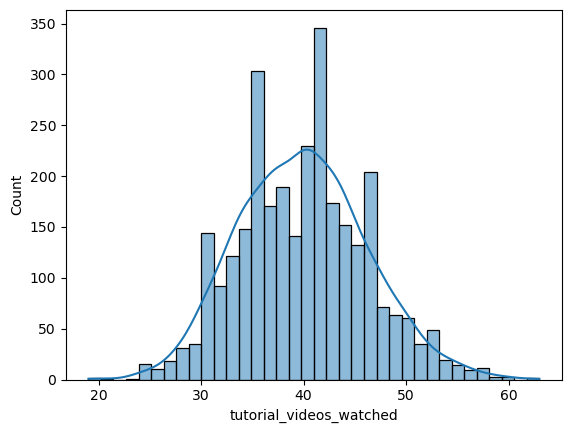

In [25]:
sns.histplot(x = "tutorial_videos_watched", kde=True,data=df)

- The distribution of tutorial videos watched is approximately normal.
- The values range from 20 to 60 videos.
- The highest concentration of students watched around 35 to 45 videos, making it the most common range.

<Axes: xlabel='uses_kaggle', ylabel='count'>

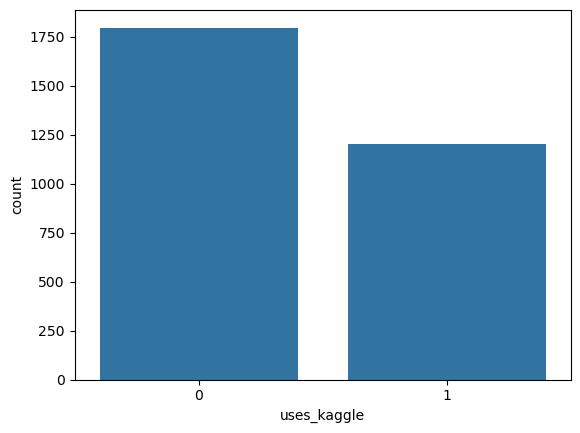

In [26]:
sns.countplot(x= "uses_kaggle",data=df)

- Out of all students, around 1,750 do NOT use Kaggle, which forms the majority.
- The remaining group (much smaller) actively uses Kaggle.
- This indicates that Kaggle usage is not common among students in this dataset.

<Axes: xlabel='participates_in_discussion_forums', ylabel='count'>

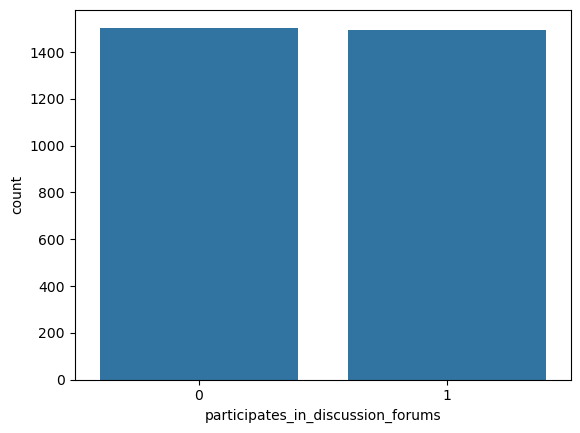

In [27]:
sns.countplot(x=df["participates_in_discussion_forums"])

- The number of students who participate in discussion forums and those who don’t is almost the same.
- This means forum participation is evenly split among the student population.

<Axes: xlabel='debugging_sessions_per_week', ylabel='Count'>

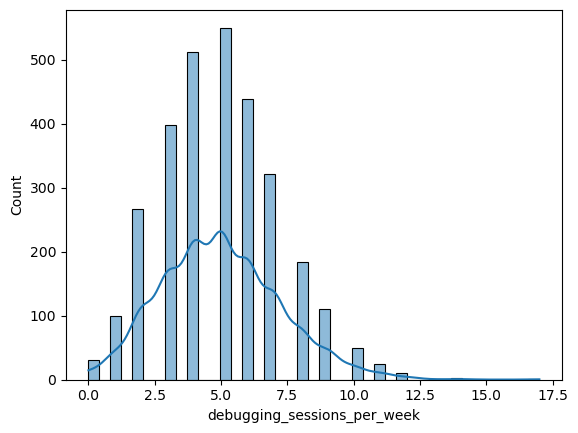

In [28]:
sns.histplot(df["debugging_sessions_per_week"],kde=True)

- The distribution of debugging sessions per week is not continuous.
- The data is right-skewed, meaning more students have lower debugging session counts.
- The values range from 0 to 17.5 sessions, with the highest concentration between 2.5 and 7.5 sessions per week.

<Axes: xlabel='self_reported_confidence_python', ylabel='Count'>

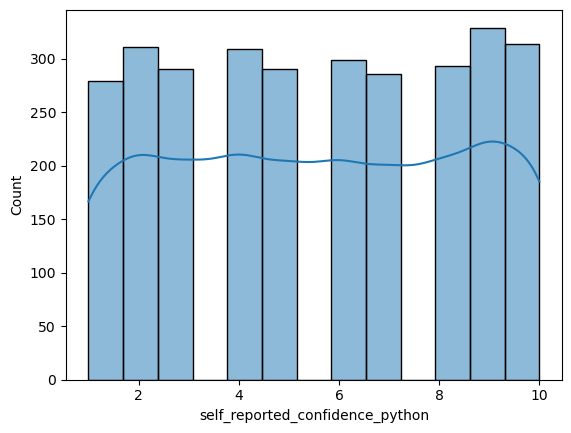

In [29]:
sns.histplot(df["self_reported_confidence_python"], kde=True)

- The self-reported Python confidence values are discrete, not continuous, ranging from 1 to 10.
- The distribution is fairly uniform, meaning students are spread almost evenly across all confidence levels.
- There is no strong skew — confidence levels appear balanced across the dataset.

<Axes: xlabel='final_exam_score', ylabel='Count'>

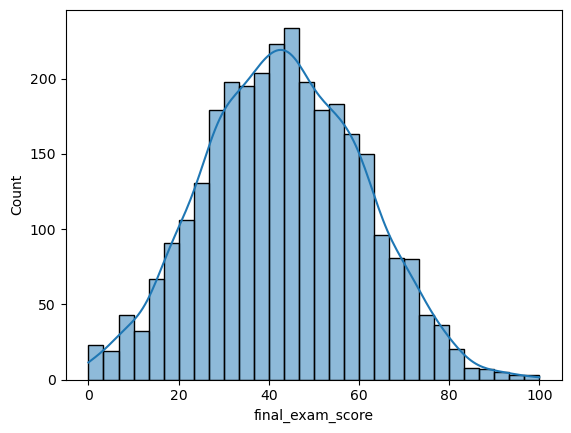

In [30]:
sns.histplot(df["final_exam_score"], kde=True)

- The final exam scores follow a roughly normal distribution.
- Scores range from 0 to 100, covering the full possible spectrum.
- The highest concentration of students scored between 22 and 65, making this the most common performance range.

### Bivariated Eda

<Axes: xlabel='passed_exam', ylabel='age'>

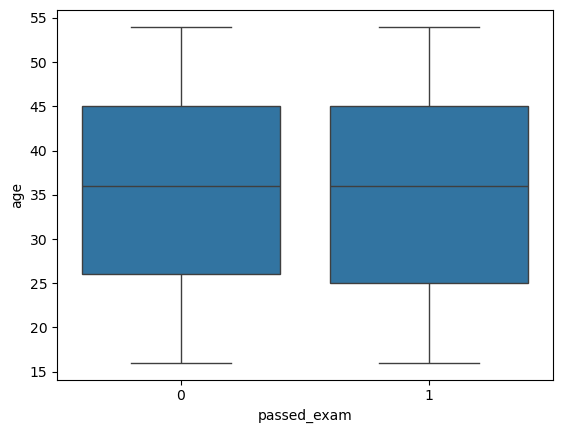

In [31]:
sns.boxplot(x="passed_exam", y="age", data=df)

- The age distribution for both passed and failed students is almost identical.
- Ages range from 16 to 55 in both groups.
- There is no meaningful difference in age between students who passed and those who failed.
- This suggests that age is not a significant factor in determining whether a student passes the exam.

<Axes: xlabel='prior_programming_experience', ylabel='count'>

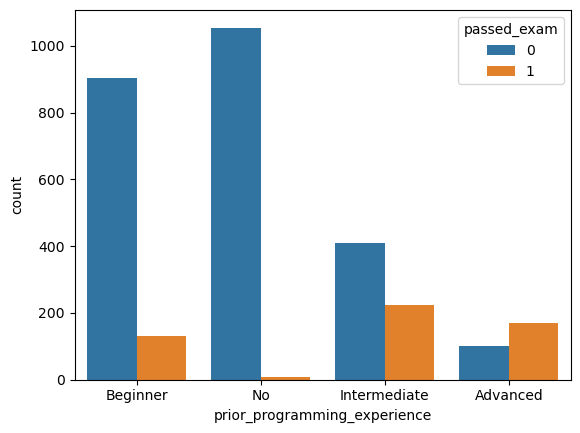

In [32]:
sns.countplot(x="prior_programming_experience", hue="passed_exam", data=df)

- Students with advanced prior programming experience have a much higher pass rate compared to other groups.
- Students with no or beginner-level experience tend to fail the exam more often.
- The intermediate group shows a balanced outcome, with pass and fail counts being almost equal.
- Overall, prior programming experience appears to be a strong predictor of exam success.

<Axes: xlabel='passed_exam', ylabel='weeks_in_course'>

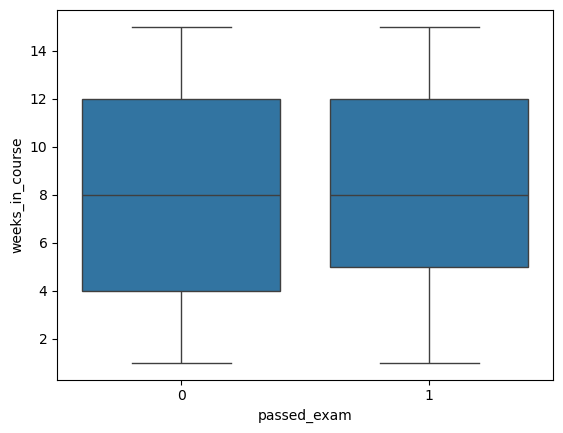

In [33]:
sns.boxplot(x="passed_exam", y="weeks_in_course", data=df)

- The distribution of weeks spent in the course is almost the same for both passed and failed students.
- There is no clear difference in how long students stayed in the course between the two groups.
- This suggests that weeks_in_course does not significantly influence whether a student passes the exam.

<Axes: xlabel='passed_exam', ylabel='hours_spent_learning_per_week'>

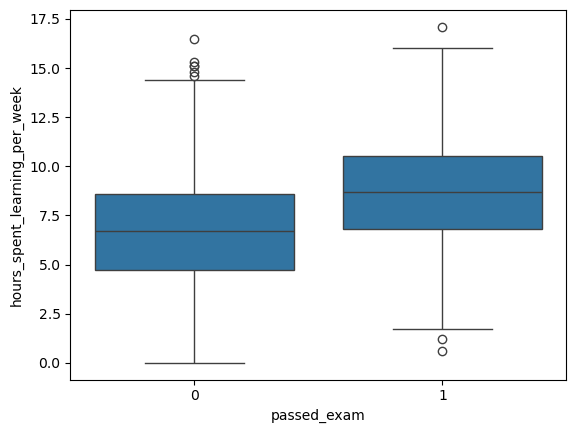

In [34]:
sns.boxplot(x="passed_exam", y="hours_spent_learning_per_week", data=df)

- Students who failed the exam generally spent 1–2 hours less per week studying compared to those who passed.
- The median study time for passed students is noticeably higher, indicating that more study hours per week is linked to better exam performance.
- This suggests that consistent study time is an important factor influencing success.

<Axes: xlabel='passed_exam', ylabel='practice_problems_solved'>

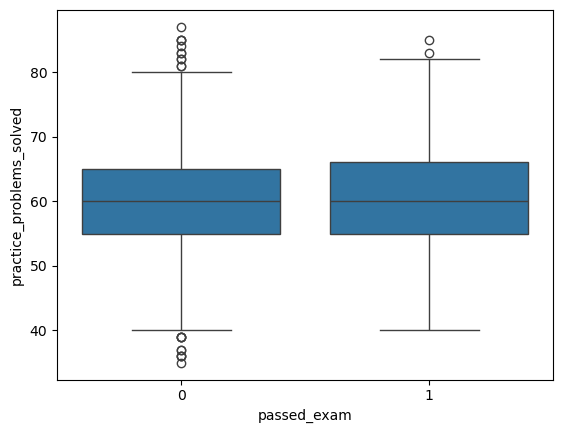

In [35]:
sns.boxplot(x="passed_exam", y="practice_problems_solved", data=df)

- After ignoring outliers, students who passed the exam generally solved 1–2 more practice problems than those who failed.
- However, there are several outliers in the failed group who solved a high number of problems, more than most of the passed students.
- This shows that while practice helps, solving a large number of problems does not guarantee exam success.

<Axes: xlabel='passed_exam', ylabel='projects_completed'>

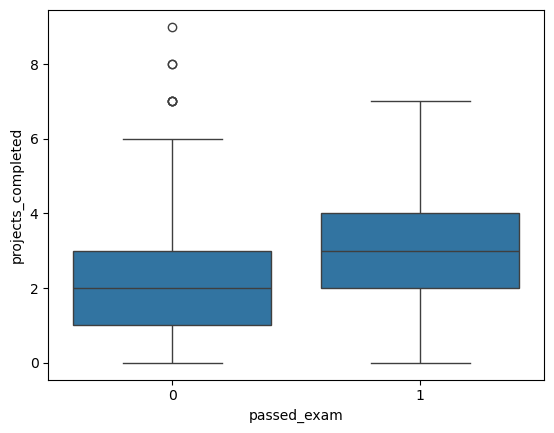

In [36]:
sns.boxplot(x="passed_exam", y="projects_completed", data=df)

- The number of projects completed is more for passed one then failed students.
- Students who passed typically completed more number of projects as those who failed.
- However, there are a few outliers in the failed group who completed 1–2 more projects than most passed students.
- This suggests that projects alone are not a strong indicator of exam success — students may complete projects without fully understanding the concepts behind them.

<Axes: xlabel='passed_exam', ylabel='tutorial_videos_watched'>

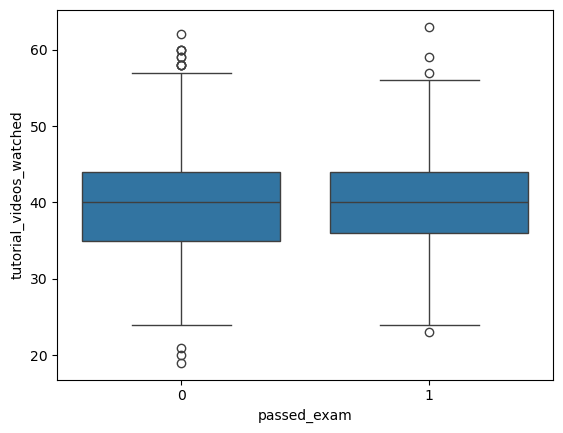

In [37]:
sns.boxplot(x="passed_exam", y="tutorial_videos_watched", data=df)

- Students who passed generally watched same no of tutorial videos as those who failed.
- However, there are some outliers in the passed group who watched a high number of videos.
- This indicates that while watching tutorials helps, simply watching more videos does not guarantee exam success — practical application and understanding are also important.

<Axes: xlabel='uses_kaggle', ylabel='count'>

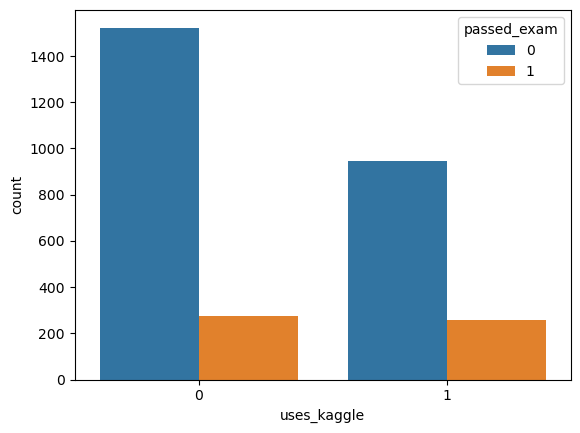

In [38]:
sns.countplot(x="uses_kaggle", hue="passed_exam", data=df)

- Most students in the dataset do not use Kaggle, forming the largest group.
- Interestingly, even among those who don’t use Kaggle, a significant number passed the exam.
- This shows that while Kaggle usage may help, it is not the only factor determining exam success — other learning activities also play a major role.

<Axes: xlabel='participates_in_discussion_forums', ylabel='count'>

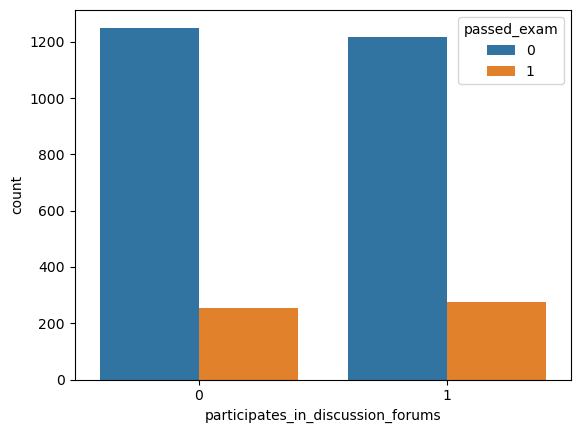

In [39]:
sns.countplot(x="participates_in_discussion_forums", hue="passed_exam", data=df)

- The number of students who participate in discussion forums and those who do not is almost the same.
- However, among those who participate, there is a slightly higher pass rate compared to non-participants.
- This suggests that active engagement in forums may contribute positively to exam success.

<Axes: xlabel='passed_exam', ylabel='debugging_sessions_per_week'>

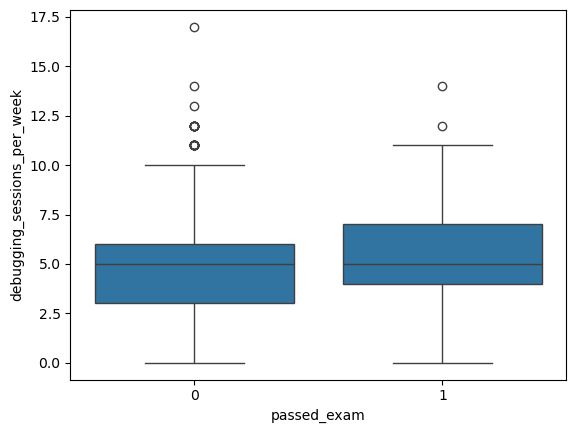

In [40]:
sns.boxplot(x="passed_exam", y="debugging_sessions_per_week", data=df)

- Students who passed the exam generally had more debugging sessions per week than those who failed.
- However, there are some outliers in the failed group who completed more debugging sessions than many of the passed students.
- This indicates that while debugging practice helps, simply doing more sessions does not guarantee success — understanding and applying the debugging effectively is also important.

<Axes: xlabel='passed_exam', ylabel='self_reported_confidence_python'>

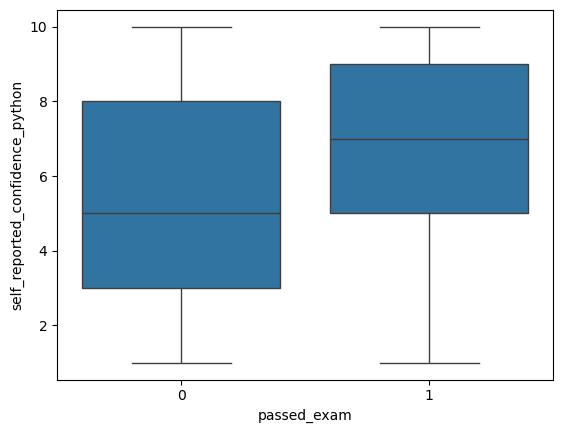

In [41]:
sns.boxplot(x="passed_exam", y="self_reported_confidence_python", data=df)

- Students who passed the exam generally have higher self-reported confidence in Python compared to those who failed.
- The spread (IQR) is also higher for passed students, indicating that most of them rate themselves confidently.
- There are outliers in both groups, but overall, higher confidence strongly correlates with passing.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Pakistan'),
  Text(1, 0, 'Nigeria'),
  Text(2, 0, 'India'),
  Text(3, 0, 'UK'),
  Text(4, 0, 'Brazil'),
  Text(5, 0, 'USA'),
  Text(6, 0, 'Bangladesh'),
  Text(7, 0, 'Germany'),
  Text(8, 0, 'Indonesia'),
  Text(9, 0, 'Other')])

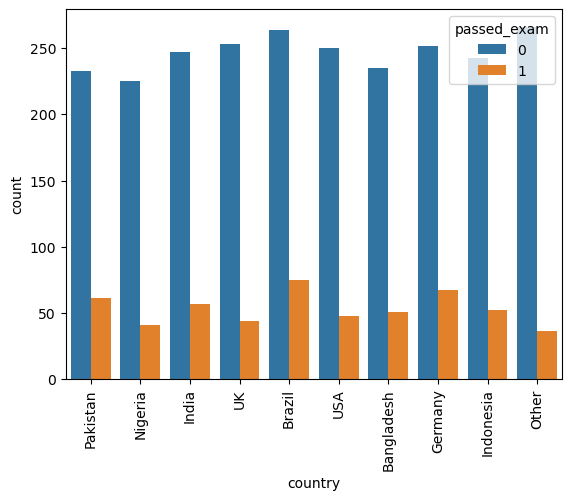

In [42]:
sns.countplot(x="country", hue="passed_exam", data=df)
plt.xticks(rotation=90)

<Axes: >

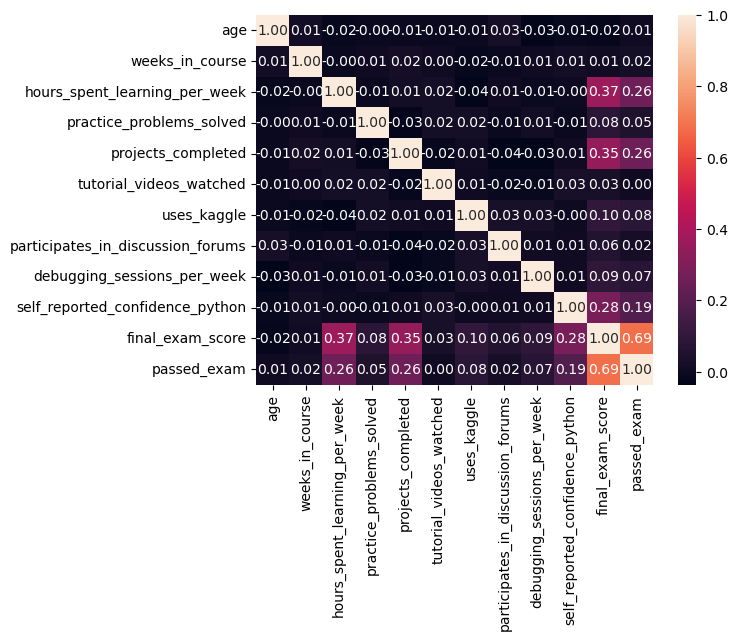

In [43]:
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f")

## FINAL EDA CONCLUSION (Ready for your report)

### Univariate Analysis Insights
- Age, study hours, videos watched, and problems solved are all fairly normally distributed.
- Projects completed and debugging sessions show right-skewed distributions.
- Confidence in Python ranges evenly across levels 1–10.

### Key Bivariate Insights
1. Factors NOT strongly associated with exam success
- Age
- Weeks in course
- Tutorial videos watched
#### These show very similar distributions for passed vs failed students.

### Factors with strong influence on passing
- Prior Programming Experience
- Students with Advanced experience pass the most.
- Students with No or Beginner experience mostly fail.
- Study Hours Per Week
- Passed students study 1–2 more hours per week on average.
- Practice Problems Solved
- Projects Completed
- Participation in Discussion Forums
- Debugging Sessions
- Self-Reported Confidence

## Feature Engineering

In [44]:
df.head()

,age,country,prior_programming_experience,weeks_in_course,hours_spent_learning_per_week,practice_problems_solved,projects_completed,tutorial_videos_watched,uses_kaggle,participates_in_discussion_forums,debugging_sessions_per_week,self_reported_confidence_python,final_exam_score,passed_exam
0,54,Pakistan,Beginner,12,12.2,60,1,24,0,1,4,10,53.8,0
1,44,Nigeria,No,15,14.2,52,1,32,0,0,5,7,31.9,0
2,30,India,Intermediate,5,7.7,71,1,43,0,0,6,3,59.4,0
3,23,Nigeria,Beginner,4,5.6,64,2,40,1,0,3,10,58.8,0
4,36,UK,No,3,3.5,62,1,47,1,0,3,7,24.8,0


In [45]:
df["country"].value_counts()

country
Brazil        339
Germany       319
India         304
Other         302
USA           298
UK            297
Indonesia     295
Pakistan      294
Bangladesh    286
Nigeria       266
Name: count, dtype: int64

In [46]:
df = pd.get_dummies(df,columns=["country"],drop_first=True,dtype=int)

In [47]:
df.head()

,age,prior_programming_experience,weeks_in_course,hours_spent_learning_per_week,practice_problems_solved,projects_completed,tutorial_videos_watched,uses_kaggle,participates_in_discussion_forums,debugging_sessions_per_week,...,passed_exam,country_Brazil,country_Germany,country_India,country_Indonesia,country_Nigeria,country_Other,country_Pakistan,country_UK,country_USA
0,54,Beginner,12,12.2,60,1,24,0,1,4,...,0,0,0,0,0,0,0,1,0,0
1,44,No,15,14.2,52,1,32,0,0,5,...,0,0,0,0,0,1,0,0,0,0
2,30,Intermediate,5,7.7,71,1,43,0,0,6,...,0,0,0,1,0,0,0,0,0,0
3,23,Beginner,4,5.6,64,2,40,1,0,3,...,0,0,0,0,0,1,0,0,0,0
4,36,No,3,3.5,62,1,47,1,0,3,...,0,0,0,0,0,0,0,0,1,0


In [48]:
df["prior_programming_experience"].value_counts()

prior_programming_experience
No              1062
Beginner        1034
Intermediate     634
Advanced         270
Name: count, dtype: int64

In [49]:
df['prior_programming_experience'] = df['prior_programming_experience'].map({'No':0, 'Beginner':1,"Intermediate":2,"Advanced":3})

In [50]:
df["engagement"] = (
    df["practice_problems_solved"] +
    df["projects_completed"] +
    df["debugging_sessions_per_week"]
)

In [51]:
df["consistency"] = df["hours_spent_learning_per_week"] / (df["weeks_in_course"] + 1)

In [52]:
df["experienced"] = df["prior_programming_experience"].apply(
    lambda x: 1 if x > 0 else 0
)


In [53]:
df.shape

(3000, 25)

In [54]:
df.head()

,age,prior_programming_experience,weeks_in_course,hours_spent_learning_per_week,practice_problems_solved,projects_completed,tutorial_videos_watched,uses_kaggle,participates_in_discussion_forums,debugging_sessions_per_week,...,country_India,country_Indonesia,country_Nigeria,country_Other,country_Pakistan,country_UK,country_USA,engagement,consistency,experienced
0,54,1,12,12.2,60,1,24,0,1,4,...,0,0,0,0,1,0,0,65,0.938462,1
1,44,0,15,14.2,52,1,32,0,0,5,...,0,0,1,0,0,0,0,58,0.887500,0
2,30,2,5,7.7,71,1,43,0,0,6,...,1,0,0,0,0,0,0,78,1.283333,1
3,23,1,4,5.6,64,2,40,1,0,3,...,0,0,1,0,0,0,0,69,1.120000,1
4,36,0,3,3.5,62,1,47,1,0,3,...,0,0,0,0,0,1,0,66,0.875000,0


In [55]:
X = df.drop(columns=['passed_exam',"final_exam_score"])
y = df["passed_exam"]

### Why we drop passed exam becoz the model will learn that if marks > 50 or wht means pass leads to trival features

In [56]:
df.columns

Index(['age', 'prior_programming_experience', 'weeks_in_course',
       'hours_spent_learning_per_week', 'practice_problems_solved',
       'projects_completed', 'tutorial_videos_watched', 'uses_kaggle',
       'participates_in_discussion_forums', 'debugging_sessions_per_week',
       'self_reported_confidence_python', 'final_exam_score', 'passed_exam',
       'country_Brazil', 'country_Germany', 'country_India',
       'country_Indonesia', 'country_Nigeria', 'country_Other',
       'country_Pakistan', 'country_UK', 'country_USA', 'engagement',
       'consistency', 'experienced'],
      dtype='object')

In [57]:
num_cols = ['age','weeks_in_course','hours_spent_learning_per_week','practice_problems_solved',
           'projects_completed','tutorial_videos_watched','debugging_sessions_per_week',
           'self_reported_confidence_python','engagement','consistency',"prior_programming_experience"]

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [60]:
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## Feature Engineering Overviwe

### Encoding Categorical Columns
- Country → Converted using One-Hot Encoding.
- Prior Programming Experience → Converted into ordered numeric values using  mapping:
  - No=0, Beginner=1, Intermediate=2, Advanced=3

### Created New Meaningful Features

#### To strengthen the model with learning-behavior insights:
1. Engagement Score 
- Measures overall student activity.
- (problems solved + projects + debugging sessions)

2. Consistency Score
- Shows how regularly the student studies.
- (study hours per week / weeks in course)

3. Experience Flag
- Simple 0/1 indicator of whether the student has any prior programming experience.

### Train–Test Split
- Dataset split into 80% training and 20% testing.

### Standard Scaling
- All numerical features were standardized using StandardScaler to ensure equal weight across features and improve model performance.

## Feature Selection 

In [61]:
df.shape

(3000, 25)

In [62]:
from sklearn.ensemble import RandomForestClassifier

In [63]:
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=500, random_state=42)

In [64]:
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

<Axes: xlabel='Importance', ylabel='Feature'>

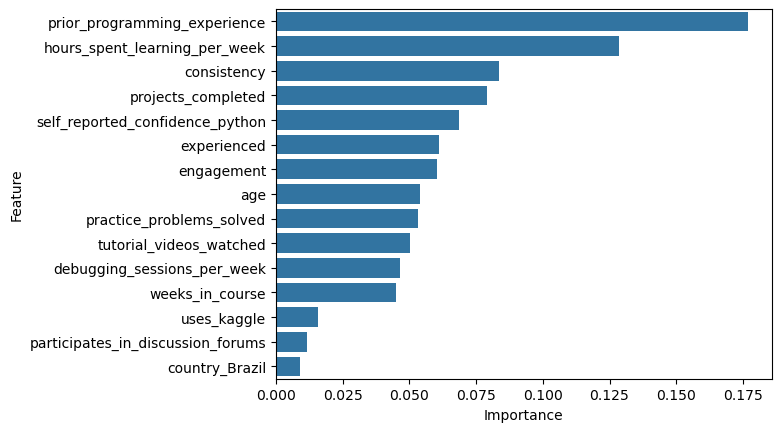

In [65]:
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(15))

In [66]:
feature_importances

,Feature,Importance
1,prior_programming_experience,0.176979
3,hours_spent_learning_per_week,0.128431
21,consistency,0.083711
5,projects_completed,0.079092
10,self_reported_confidence_python,0.068555
22,experienced,0.061254
20,engagement,0.060305
0,age,0.053877
4,practice_problems_solved,0.053103
6,tutorial_videos_watched,0.050113


In [67]:
top_features = feature_importances['Feature'].head(15).tolist()
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]
X_train_selected.columns

Index(['prior_programming_experience', 'hours_spent_learning_per_week',
       'consistency', 'projects_completed', 'self_reported_confidence_python',
       'experienced', 'engagement', 'age', 'practice_problems_solved',
       'tutorial_videos_watched', 'debugging_sessions_per_week',
       'weeks_in_course', 'uses_kaggle', 'participates_in_discussion_forums',
       'country_Brazil'],
      dtype='object')

## Feature Selection Overview
- Method Used: Tree-based feature selection using RandomForestClassifier
- Why: Handles mix of numeric and one-hot features, captures non-linear relationships, and identifies the most important features for churn prediction
- Process:
1. Fit RandomForest on the training set
2. Compute feature importances
3. Select top 15 features based on importance
- Top Features Selected: prior_programming_experience, hours_spent_learning_per_week, consistency, projects_completed, self_reported_confidence_python, experienced, engagement, age, practice_problems_solved, tutorial_videos_watched, debugging_sessions_per_week, weeks_in_course, uses_kaggle, participates_in_discussion_forums, country_Brazil
- Result: Dataset reduced to top 15 features, ready for modeling.

## Model Selection

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [69]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier()
}

In [70]:
results = []
for name, model in models.items():
    model.fit(X_train_selected, y_train)                    
    y_pred = model.predict(X_test_selected)                 
    y_prob = model.predict_proba(X_test_selected)[:,1]      
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

In [71]:
results_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.923333,0.835165,0.710280,0.767677,0.952513
1,Random Forest,0.905000,0.867647,0.551402,0.674286,0.929783
2,XGBoost,0.900000,0.764045,0.635514,0.693878,0.923205


## Model Selection Overview
- Models Trained: Logistic Regression, Random Forest, XGBoost
-Evaluation Metrics Used: Accuracy, Precision, Recall, F1-Score, ROC-AUC
- Results Overview:
1. Logistic Regression: Accuracy = 0.923, ROC-AUC = 0.952
2. Random Forest: Accuracy = 0.905, ROC-AUC = 0.930
3. XGBoost: Accuracy = 0.900, ROC-AUC = 0.923
- Best Model Selected: Logistic Regression
- Reason: Highest ROC-AUC and strong overall metrics; simple and best.

## Hyperparameter Tuning On Best Model

In [72]:
from sklearn.model_selection import GridSearchCV

In [73]:
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'max_iter': [1000]
}
logreg = LogisticRegression(random_state=42)

In [74]:
grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

In [75]:
grid_search.fit(X_train_selected, y_train)


Fitting 5 folds for each of 60 candidates, totalling 300 fits


GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'max_iter': [1000],
                         'penalty': ['l1', 'l2', 'elasticnet', 'none'],
                         'solver': ['lbfgs', 'liblinear', 'saga']},
             scoring='roc_auc', verbose=1)

In [76]:
grid_search.best_params_

{'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}

In [77]:
grid_search.best_score_

np.float64(0.9545078183172002)

## Hyperparameter Tuning & Final Model
- Model: Logistic Regression
- Hyperparameter Tuning: GridSearchCV with 5-fold cross-validation
- Parameters Tuned: penalty, C, solver, max_iter
- Scoring Metric: ROC-AUC (best for imbalanced churn data)
- Best Parameters Found:
1. C: 1
2. penalty: 'l2'
3. solver: 'saga'
4. max_iter: 1000

## Training Model With Best Parameter

In [78]:
bestlog = LogisticRegression(C =  10, max_iter =  1000, penalty= 'l2', solver= 'saga')
bestlog.fit(X_train_selected,y_train)

LogisticRegression(C=10, max_iter=1000, solver='saga')

In [79]:
y_pred = bestlog.predict(X_test_selected)
y_prob = bestlog.predict_proba(X_test_selected)[:,1]

In [80]:
accuracy_score(y_test, y_pred)

0.925

In [81]:
roc_auc_score(y_test, y_prob)

np.float64(0.9527781463858505)

## Final Model Training Summary
- Model Selected: Logistic Regression
- Reason: Highest ROC-AUC (0.95) and strong overall metrics among trained models

In [82]:
import pickle
with open('logreg_python_model.pkl', 'wb') as file:
    pickle.dump(bestlog, file)

In [83]:
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

# Final Project Summary: Student Performance Prediction

## 1. Project Goal and Scope
This project focused on developing a machine learning model to predict student outcomes (**Pass/Fail**) in an online programming course. The primary objective was to analyze learning behavior patterns to identify students at high risk of failing early in the course, enabling timely and targeted intervention.

## 2. Dataset and Initial Features
The analysis was based on a dataset of **3,000 student records**. The initial feature set consisted of 15 attributes, covering four main categories:
* **Demographics:** `age`, `country`.
* **Background:** `prior_programming_experience`.
* **Study Habits:** `hours_spent_learning_per_week`, `weeks_in_course`.
* **Engagement:** `practice_problems_solved`, `projects_completed`, `debugging_sessions_per_week`.
* **Target Variable:** `passed_exam` (Binary: Pass/Fail).

## 3. Data Preprocessing and Engineering
The data pipeline ensured high-quality input for the model:
* **Cleaning:** Handled approximately 1,060 missing values in the `prior_programming_experience` column by imputing them as "No" experience. The unique identifier (`student_id`) was removed.
* **Categorical Encoding:** One-Hot Encoding was applied to nominal features like `country`, and Ordinal Encoding was used for `prior_programming_experience`.
* **Feature Engineering:** New, highly predictive features were created:
    * **`engagement`**: A composite score reflecting total activity (problems solved, projects completed, etc.).
    * **`consistency`**: A normalized metric (study hours / weeks in course) to measure sustained effort.
    * **`Experience Flag`**: Simple 0/1 indicator of whether the student has any prior programming experience.

## 4. Feature Selection and Model Training
**Feature Selection:** Random Forest Feature Importance was utilized to rank predictors, resulting in the selection of the **Top 15 features** for the final model. The most critical predictors identified were `prior_programming_experience`, `hours_spent_learning_per_week`, and the engineered `consistency` score.

**Model Selection:** Three classification algorithms were evaluated: Logistic Regression, Random Forest, and XGBoost. The metric prioritized for selection was **ROC-AUC** due to the class imbalance (high number of failures vs. passes).

## 5. Final Results and Conclusion
The **Logistic Regression** model performed the best across all metrics after being optimized using GridSearchCV.
- ROC-AUC -> 0.95
- Accuracy -> 92.5%

**Key Project Findings:**
The analysis conclusively demonstrates that a student's **prior programming experience** and the **consistency of their weekly study habits** are the strongest and most reliable indicators of final exam success, far outweighing simple demographic variables like age. The deployed model provides an effective and interpretable tool for early risk prediction.

# Final Project Summary: Student Performance Prediction

**Objective:**
Predict student academic outcome (**Pass/Fail**) in an online programming course using behavioral and demographic data to enable proactive intervention strategies.

**Dataset:**
- Approx. **3,000 students**. Features include demographics, prior experience, study metrics, and engagement metrics.
- Target variable: **passed_exam**.

## Steps Taken:

### Exploratory Data Analysis (EDA):
* Analyzed target variable distribution, revealing a significant class imbalance (high failure rate).
* Visualized relationships showing that **Prior Experience** and **Study Hours** are strong predictors of success.
* Determined that variables like age and weeks_in_course are weak predictors.

### Data Cleaning & Feature Engineering:
* Handled missing values in prior_programming_experience by imputing "No".
* Converted categorical features (e.g., country) using appropriate encoding methods.
* **Derived features:**
    * **engagement**: A composite score of total learning activities.
    * **consistency**: hours_spent_learning_per_week divided by weeks_in_course to normalize effort.
    * **Experience Flag**: Simple 0/1 indicator of whether the student has any prior programming experience.
* Scaled numeric features and addressed data imbalance during model training.

### Feature Selection:
* Used **RandomForestClassifier** feature importance ranking to select the **top 15** most predictive features.
* Features like prior_programming_experience, hours_spent_learning_per_week, and the engineered consistency score were found to be most influential.

### Model Training & Evaluation:
* Trained and evaluated three models: Logistic Regression, RandomForest, and XGBoost.
* Selected **Logistic Regression** as the best performing model based on its superior **ROC-AUC score**, which is critical for imbalanced data.

### Hyperparameter Tuning:
* Used **GridSearchCV** with 5-fold cross-validation (CV) on the Logistic Regression model.
* Best parameters found: C=1, penalty='l2', solver='saga', max_iter=1000.

#### Results:
**Metric Score:**
Accuracy: **92.5%**
ROC-AUC: **0.95**

## Insights & Impact:
* Students with **Advanced prior programming experience** and **high study consistency** are overwhelmingly likely to pass.
* **High engagement** (completing projects and practice problems) is strongly correlated with success.
* The model enables the identification of low-consistency and low-experience students who can be targeted with **personalized interventions** (e.g., mandatory tutoring, structured study plans) to improve pass rates.